# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [42]:
import matplotlib.pyplot as plt
import numpy
import pandas
import seaborn
seaborn.set_context('talk')

In [43]:
# Cargamos los datos
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Información acerca de las variables
Suburb: Suburb

Address: Dirección

Rooms: Número de habitaciones

Price: Precio en dólares australianos

Method:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

Type:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

SellerG: Agente inmobiliario

Date: Fecha de venta

Distance: Distancia al CBD en kilómetros

Regionname: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

Propertycount: Número de propiedades existentes en el suburbio.

Bedroom2 : Número de dormitorios (obtenido de otra fuente)

Bathroom: Número de baños

Car: Número de plazas de aparcamiento

Landsize: Tamaño del terreno en metros cuadrados

BuildingArea: Superficie construida en metros cuadrados

YearBuilt: Año de construcción de la casa

CouncilArea: Área del consejo municipal

Lattitude: Latitud

Longtitude: Longitud


In [44]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


#Resolución Ej 1

###Análisis exploratorio previo

Antes de transformar los datos, exploramos su estructura, valores faltantes y ceros para tomar decisiones fundamentales sobre qué conservar, eliminar o corregir.


In [45]:
#Excluimos BuildingArea y YearBuilt según  el enunciado (se recuperan en Ej. 2)
melb_df_ej1 = melb_df.drop(['BuildingArea', 'YearBuilt'], axis=1).copy()

In [46]:
# Visión general del dataset
melb_df_ej1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

In [47]:
# Verificacion de types en las variables numericas
melb_df_ej1.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [48]:
import pandas as pd

# Valores faltantes y ceros por columna
faltantes = melb_df_ej1.isna().sum()
ceros = (melb_df_ej1 == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes, 'Ceros': ceros})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
Distance,0,6
Bedroom2,0,16
Bathroom,0,34
Car,62,1026
Landsize,0,1939
CouncilArea,1369,0


Decisiones sobre datos faltantes y ceros:



*   **Car**: el cero ya existe como sin cochera, por lo que los NaN parecen errores de registro. Se eliminan esas filas (son pocas).
*   **CouncilArea**: variable categórica con algunos faltantes. Se conservan las filas creando una nueva categoría 'Desconocido' para no perder observaciones.
*   **Distance = 0**: todos los registros con distancia 0 corresponden al suburbio Melbourne (centro de la ciudad). Se considera un valor válido.
*   **Bathroom = 0**: una propiedad habitable no puede tener 0 baños. Se trata como faltante y se eliminan esas filas.
*  **Bedrrom2**: varibale redundande con Rooms (misma información, distinta fuente). Se elimina.
*  **Address** y **SellerG**: cardinalidad alta (casi una categoría por fila). No aportan generalización. Se eliminan.







In [49]:
# Aplicamos la limpieza
melb_df_ej1 = melb_df_ej1.dropna(subset=['Car'])                          # Car: eliminar faltantes
melb_df_ej1['CouncilArea'] = melb_df_ej1['CouncilArea'].fillna('Desconocido')  # CouncilArea: nueva categoría
melb_df_ej1.loc[melb_df_ej1['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df_ej1 = melb_df_ej1.dropna(subset=['Bathroom'])                     # Bathroom = 0: inválido
melb_df_ej1 = melb_df_ej1.drop(columns=['Bedroom2', 'Address', 'SellerG'], errors='ignore')  # columnas redundantes/alta cardinalidad
print(f'Filas restantes: {melb_df_ej1.shape[0]}')

Filas restantes: 13484


<Axes: >

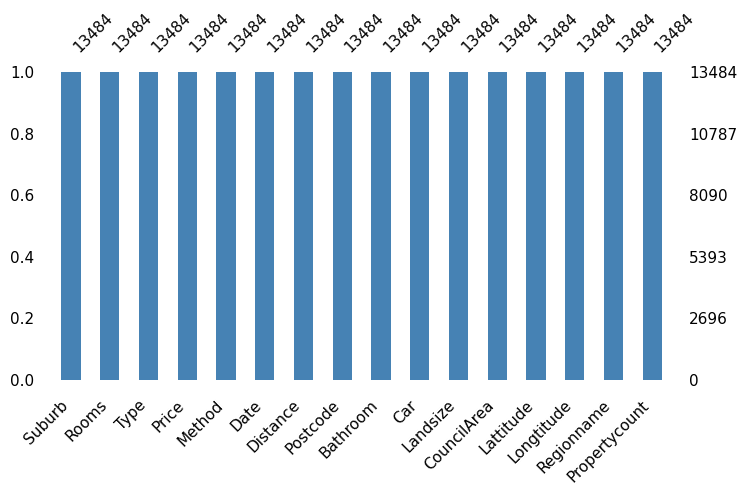

In [50]:
# Visualización del dataset tras la limpieza
import missingno as msno
msno.bar(melb_df_ej1, figsize=(8, 4), sort='ascending', fontsize=11, color='steelblue')

### Análisis descriptivo de variables numéricas

Verificamos los tipos de datos asignados y revisamos estadísticas descriptivas para detectar anomalías.

In [51]:
melb_df_ej1.dtypes

,0
Suburb,object
Rooms,int64
Type,object
Price,float64
Method,object
Date,object
Distance,float64
Postcode,float64
Bathroom,float64
Car,float64


In [52]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = melb_df_ej1.select_dtypes(include=['int64', 'float64']).columns
melb_df_ej1[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13484.0,2.940967e+00,0.956714,1.00000,2.00000,3.000000,3.000000e+00,1.000000e+01
Price,13484.0,1.075251e+06,640304.969219,85000.00000,650000.00000,901000.000000,1.330000e+06,9.000000e+06
Distance,13484.0,1.016466e+01,5.865301,0.00000,6.20000,9.200000,1.300000e+01,4.810000e+01
Postcode,13484.0,3.105213e+03,90.790360,3000.00000,3044.00000,3084.000000,3.148000e+03,3.977000e+03
Bathroom,13484.0,1.539232e+00,0.688870,1.00000,1.00000,1.000000,2.000000e+00,8.000000e+00
Car,13484.0,1.614061e+00,0.960527,0.00000,1.00000,2.000000,2.000000e+00,1.000000e+01
Landsize,13484.0,5.588735e+02,4003.162685,0.00000,178.00000,443.000000,6.510000e+02,4.330140e+05
Lattitude,13484.0,-3.780915e+01,0.079414,-38.18255,-37.85700,-37.802200,-3.775610e+01,-3.740853e+01
Longtitude,13484.0,1.449953e+02,0.104086,144.43181,144.92923,145.000275,1.450586e+02,1.455264e+02
Propertycount,13484.0,7.454352e+03,4382.042359,249.00000,4380.00000,6567.000000,1.033100e+04,2.165000e+04


Observaciones sobre las variables numéricas:



*   **Price:** el máximo (9.000.000) está muy alejado del percentil 75 (1.330.000), lo que indica la presencia de outliers en precios muy altos. Se filtrará por percentil 99.
*   **Landsize**: mínimo de 0 y máximo de 433.014 con el 75% en apenas 651 m2. Los ceros probablemente sean datos faltantes mal codificados y los valores extremos son outliers. Se reemplazarán los ceros por NaN y se filtrará por percentil 99.
*   **Postcode**: aunque figura como numérico, es un código postal. Se tratará como variable categórica.
*  **Date**: no aparece en la tabla porque es tipo 'object'. Se convertirá en datetime y se extraerán el año y el mes como variable numéricas en la resolución.

El resto de las variables numéricas (Rooms, Bathroon, Car, Distance) tienen rangos razonables.





### Análisis de Variables Categóricas

Analizamos cuántos valores únicos tiene cada variable categórica para decidir cuáles aplicar OHE y cuáles reducir o descartar.

In [53]:
cat_cols = melb_df_ej1.select_dtypes(include='object').columns
cardinalidad = melb_df_ej1[cat_cols].nunique().sort_values(ascending=False)
print(cardinalidad)

Suburb         314
Date            58
CouncilArea     34
Regionname       8
Method           5
Type             3
dtype: int64


In [54]:
# Identificar las variables categoricas del dataset
melb_df_ej1.select_dtypes(include=['object'])

,Suburb,Type,Method,Date,CouncilArea,Regionname
0,Abbotsford,h,S,3/12/2016,Yarra,Northern Metropolitan
1,Abbotsford,h,S,4/02/2016,Yarra,Northern Metropolitan
2,Abbotsford,h,SP,4/03/2017,Yarra,Northern Metropolitan
3,Abbotsford,h,PI,4/03/2017,Yarra,Northern Metropolitan
4,Abbotsford,h,VB,4/06/2016,Yarra,Northern Metropolitan
...,...,...,...,...,...,...
13575,Wheelers Hill,h,S,26/08/2017,Desconocido,South-Eastern Metropolitan
13576,Williamstown,h,SP,26/08/2017,Desconocido,Western Metropolitan
13577,Williamstown,h,S,26/08/2017,Desconocido,Western Metropolitan
13578,Williamstown,h,PI,26/08/2017,Desconocido,Western Metropolitan


Selección para OHE:



*   Variables con baja cardinalidad (< 15 categorías): Type, Method, Regionname. OHE
*   Variables con cardinalidad media (CouncilArea, Suburb): se reducen conservando las N categorías más frecuentes y agrupando el resto en 'Other'.
*   Variables con cardinalidad alta (Address, SellerG): ya eliminadas en el paso anterior.





Con base en el análisis anterior, se aplica  encoding y armado de la matriz final.

Se convierte 'Date' a formato datetime y se extraen el año y el mes como variables numéricas. La columna original se elimina porque tiene 58 valores únicos, lo que dificulta la aplicación de OHE directamente.

In [55]:
import pandas as pd

if 'Date' in melb_df_ej1.columns:
    melb_df_ej1['Date'] = pd.to_datetime(melb_df_ej1['Date'], dayfirst=True)
    melb_df_ej1['SaleYear']  = melb_df_ej1['Date'].dt.year
    melb_df_ej1['SaleMonth'] = melb_df_ej1['Date'].dt.month
    melb_df_ej1 = melb_df_ej1.drop(columns=['Date'])
else:
    print(" 'Date' ya fue procesada previamente.")

# Postcode lo tratamos como categórico
# Add a check for 'Postcode' column for robustness
if 'Postcode' in melb_df_ej1.columns:
    melb_df_ej1['Postcode'] = melb_df_ej1['Postcode'].astype(str)

'CouncilArea' y 'Suburb'tiene cardinalidad media-alta (33 y 314 categorías). Para evitar sobrecarga la cantidad de columnas al aplicar OHE, se conservan solo las N categorías más frecuentes y el resto se agrupa en 'Other'.

In [56]:
# Reducimos cardinalidad de CouncilArea y Suburb
top_councils = melb_df_ej1['CouncilArea'].value_counts().nlargest(20).index
melb_df_ej1['CouncilArea'] = melb_df_ej1['CouncilArea'].where(
    melb_df_ej1['CouncilArea'].isin(top_councils), other='Other')

top_suburbs = melb_df_ej1['Suburb'].value_counts().nlargest(30).index
melb_df_ej1['Suburb'] = melb_df_ej1['Suburb'].where(
    melb_df_ej1['Suburb'].isin(top_suburbs), other='Other')

Se aplica One-Hot-Encoding a las variables categóricas seleccionadas. Luego se concatenan horizontalmente con la matriz numérica usando 'numpy,hstack', obteniendo la matriz final 'X' que será usada en los ejercicios siguientes.

In [57]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

cat_cols = ['Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea', 'Postcode']
num_cols = melb_df_ej1.select_dtypes(include='number').columns.tolist()

X_num = melb_df_ej1[num_cols].values
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(melb_df_ej1[cat_cols])

X = np.hstack([X_num, X_cat])
print("Shape final:", X.shape)

Shape final: (13484, 277)


**Conclusión Ej 1**

A partir del análisis exploratorio, se tomaron decisiones fundamentadas sobre cada variable. Se excluyeron 'BuildingArea' y 'YearBuilt' por alta cardinalidad o redundancia con otras columnas. Los valores faltantes se trataron de forma diferenciada: las filas con 'Car' o 'Bathroom' nulos se eliminaron por ser pocas y representar registros inválidos, mientras que las faltantes de 'CouncilArea' se conservaron creando la categoría 'Desconocido' para no perder observaciones.

Para las variables con outliers extremos ('Price' y 'Landsize') se aplicó un filtro por percentil 99. La variable 'Date' se descompuso en año y mes para incoportar la información temporal sin generar alta cardinalidad.

'Postcode' se convirtió a variable categórica por ser un código y no una magnitud numérica. Finalmente, 'Suburb' y 'CouncilArea' se redujeron a sus categorías más frecuentes antes de aplicar OHE, obteniendo una matriz para usar en los ej siguientes.

## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [58]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

## Resolución Ej 2

1. Agregamos las columnas de YearBuilt y BuildingArea del dataset original y las agregamos con sus NaN originales.

In [59]:
# 1. Agregamos YearBuilt y BuildingArea del dataset original con sus NaN
extra = melb_df.loc[melb_df_ej1.index, ['YearBuilt', 'BuildingArea']].values

2. ¿Es necesario estandarizar o escalar los datos previamente?

KNN para imputar funciona buscando las filas más similares a la que tiene el valor faltante, y usa vecinos para estimar el valor. Para medir la similitud calcula distancias entre filas.

El problema es que si una columna tiene valores 0 y 1.000.000 (como Price) y otra tiene valores entre 0 y 10 (como Rooms), la distancia va a estar dominada casi completamente por Price. Las demás columnas prácticamente no van a influir en qué vecinos se eligen.

Entonces sí, es necesario escalar. Se usa MinMaxScaler que lleva todos los valores al rango [0,1].


In [60]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Combinamos variables numéricas con YearBuilt y BuildingArea
X_para_imputar = np.hstack([X_num, extra])

# Escalamos antes de imputar
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_para_imputar)

# Imputación con la media (SimpleImputer)
simple_imputer = SimpleImputer(strategy='mean')
X_imputed_mean = simple_imputer.fit_transform(X_scaled)

# Imputación con KNN (IterativeImputer)
knn_imputer = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=3),
    max_iter=20,
    random_state=42
)
X_imputed = knn_imputer.fit_transform(X_scaled)

print("Shape después de imputar:", X_imputed.shape)

Shape después de imputar: (13484, 13)


**Comparación de distribuciones antes y después de la imputación**

Para evaluar la calidad de la imputación, comparamos la distribución de 'YearBuilt' y 'BuildingArea' en tres escenarios:


*   **Original (sin NaN):** los valores que existían antes de imputar, ignorando los faltantes.
*   **Imputando con media** ('SimpleImputer): todos los NaN se reemplazan por el promedio de la columna. Es simple pero puede distorsionar la distribución.

*   **Imputado con KNN** ('Iterative Imputer'): cada NaN se estima usando las filas más similares. Se espera que preserve mejor la forma de la distribución original.

Si el método es bueno, el histograma imputado debería parecerse al original. Si difiere mucho, indica que el modelo no encontró vecinos representativos o que la variable tiene muy pocos datos válidos.




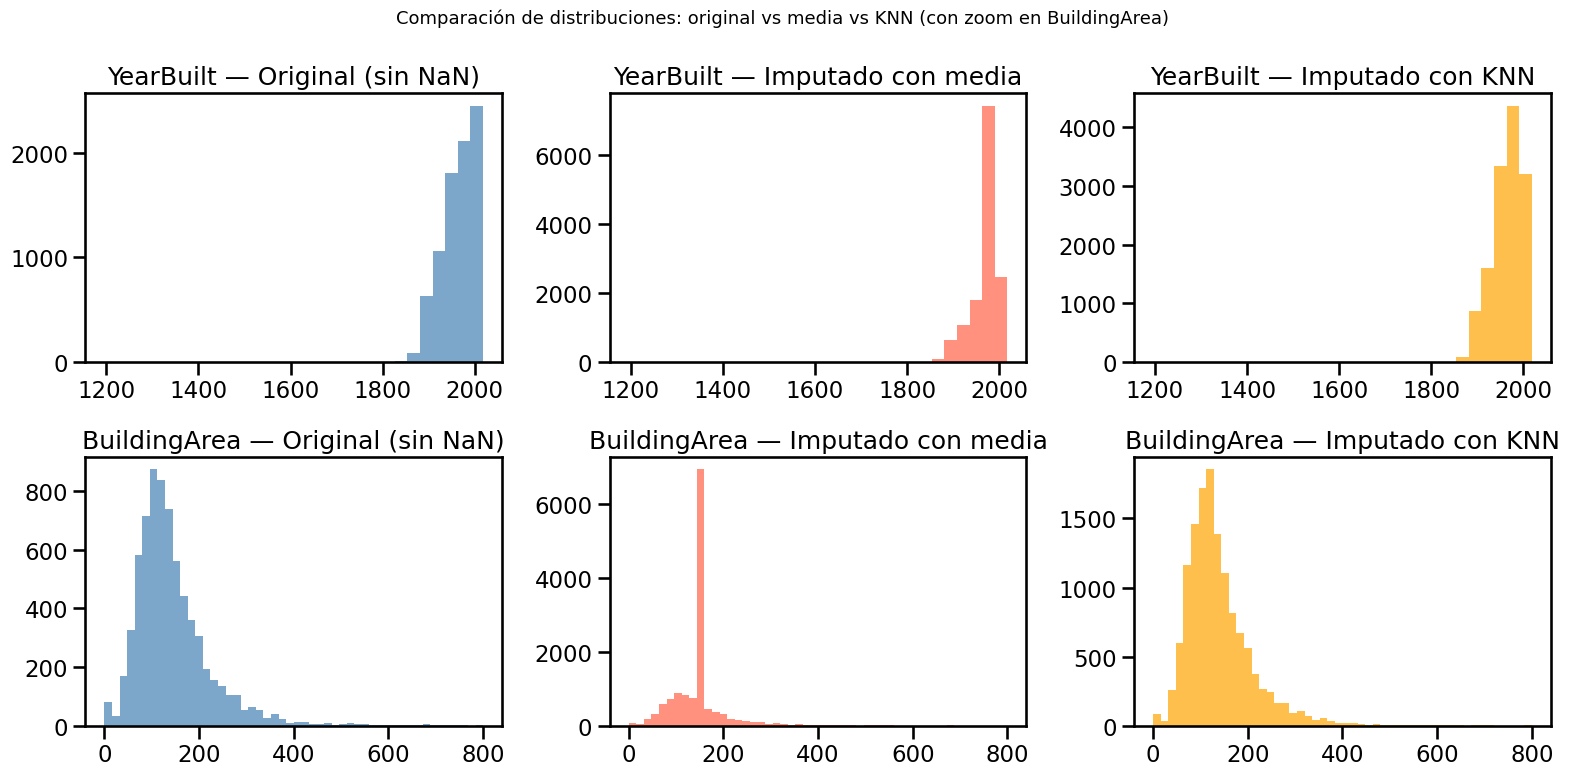

In [68]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

nombres = ['YearBuilt', 'BuildingArea']
idx_year     = X_para_imputar.shape[1] - 2
idx_building = X_para_imputar.shape[1] - 1

for i, (nombre, idx) in enumerate(zip(nombres, [idx_year, idx_building])):
    col_min = scaler.data_min_[idx]
    col_max = scaler.data_max_[idx]

    valores_originales = extra[:, i]
    sin_nan = valores_originales[~np.isnan(valores_originales)]
    valores_media = X_imputed_mean[:, idx] * (col_max - col_min) + col_min
    valores_knn = X_imputed[:, idx] * (col_max - col_min) + col_min

    # Configuración de rango dinámico para BuildingArea
    # Limitamos el eje X a 800 m2 para visualizar la distribución principal sin outliers
    rango = (0, 800) if nombre == 'BuildingArea' else None
    bins_count = 50 if nombre == 'BuildingArea' else 30

    axes[i][0].hist(sin_nan, bins=bins_count, range=rango, color='steelblue', alpha=0.7)
    axes[i][0].set_title(f'{nombre} — Original (sin NaN)')

    axes[i][1].hist(valores_media, bins=bins_count, range=rango, color='tomato', alpha=0.7)
    axes[i][1].set_title(f'{nombre} — Imputado con media')

    axes[i][2].hist(valores_knn, bins=bins_count, range=rango, color='orange', alpha=0.7)
    axes[i][2].set_title(f'{nombre} — Imputado con KNN')

plt.suptitle('Comparación de distribuciones: original vs media vs KNN (con zoom en BuildingArea)', fontsize=13)
plt.tight_layout()
plt.show()

**Gráficos de YearBuilt:**


*   **Original**:  distribución concentrada entre 1900 y 2000, con pico fuerte cerca de 2000.
*   **Media**: genera un pico artificial gigante alrededor de 1970 (el promedio), distorsionando la distribución.
*   **KNN:** preserva la forma original, con la misma concentración hacia años recientes.


**Gráficos de BuildingArea:**


*   **Original**:  muy sesgada a la derecha, la mayoría de las propiedades tienen áreas pequeñas.
*   **Media**: igual que antes, pico artificial en el valor promedio (150 m2).
*   **KNN:** mantiene la forma sesgada que el original.

**Conclusión gráficos:**

En los gráficos se observa que la imputación con la media introduce un pico artificial en el valor promedio que no existía en la distribución original, distorsionando la forma real de los datos. Esto es visible principalmente en 'YearBuilt', donde el pico de la media no refleja ningún patrón real.

La imputación con KNN, en cambio, preserva la forma general de ambas distribuciones y los valores imputados de manera coherente con los datos existentes. Esto lo convierte en el método más adecuado cuando se quiere mantener la estructura real del dataset.


## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

## Resolución Ej 3

Se tiene una matriz con muchas columnas que están correlacionadas entre sí y tienen información redundante. PCA busca nuevas direcciones en los datos que capturen la mayor varianza posible y proyecta todos ahí.

Se obtiene componentes nuevas, ordenadas de mayor a menor varianza explicada. Las primeras capturan la mayor parte de la información relevante.

1. ¿Es necesario escalar antes de PCA?

Si, PCA busca las direcciones de mayor varianza. Si las variables tienen escalas
muy distintas, las de mayor magnitud van a dominar el análisis sin
necesariamente ser más informativas.

En este caso 'X_imputed' ya fue escalado con 'MinMaxScaler'  en el ejercicio
anterior, por lo que todas las variables están en el rango [0,1].
No es necesario escalar de nuevo.

Aplicamos PCA sobre 'X_imputed' (variables numéricas + 'YearBuilt' +
'BuildingArea') y no sobre 'X' completa, porque las columnas OHE son
binarias y no aportan varianza continua útil para PCA.

1. **PCA Numérico**:

Se aplicó sobre las variables continuas imputadas.

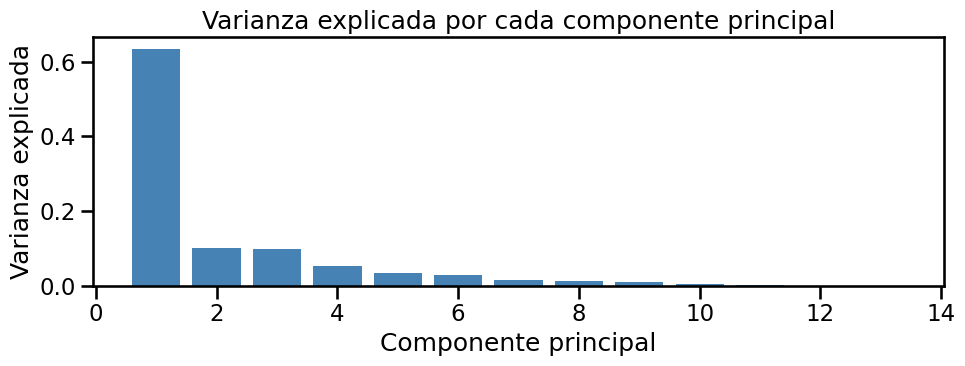

Varianza explicada por las 2 primeras componentes: 0.735
Shape PCA (2 componentes): (13484, 2)


In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# n = mínimo entre 20 y la cantidad de columnas disponibles
n_components = min(20, X_imputed.shape[1])

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_imputed)

# Varianza explicada por cada componente
plt.figure(figsize=(10, 4))
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_, color='steelblue')
plt.xlabel('Componente principal')
plt.ylabel('Varianza explicada')
plt.title('Varianza explicada por cada componente principal')
plt.tight_layout()
plt.show()

print("Varianza explicada por las 2 primeras componentes:",
      pca.explained_variance_ratio_[:2].sum().round(3))

# Tomamos las 2 primeras componentes para agregar como nuevas features
X_pca_2 = X_pca[:, :2]
print("Shape PCA (2 componentes):", X_pca_2.shape)

La primera componente explica el 63% de la varianza, junto con la segunda alcanzan el 73,5%. La caída es muy pronunciada desde la tercera componente en adelante, lo que indica que la mayor parte de la información relevante del dataset está concentrada en pocas dimensiones.

Para ver cuánto aporta cada variable original a cada componente mirando los loadings, que son los pesos que PCA le asigna a cada variable.

In [63]:
import pandas as pd

# Nombres de las columnas de X_imputed
# X_num viene de melb_df_ej1 numéricas + YearBuilt + BuildingArea al final
nombres_cols = num_cols + ['YearBuilt', 'BuildingArea']

# Loadings de las 2 primeras componentes
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=nombres_cols,
    columns=['Componente 1', 'Componente 2']
).round(3)

print(loadings.sort_values('Componente 1', ascending=False))

               Componente 1  Componente 2
SaleYear              0.968        -0.057
Distance              0.060        -0.115
Rooms                 0.020        -0.112
Car                   0.015        -0.059
Longtitude            0.014         0.005
YearBuilt             0.008        -0.006
Bathroom              0.008        -0.076
Landsize              0.001        -0.001
Price                 0.000        -0.037
BuildingArea          0.000        -0.002
Lattitude            -0.001         0.038
Propertycount        -0.003         0.938
SaleMonth            -0.242        -0.282


La primera componente principal está dominada por 'SaleYear' (loading=0.968), lo que indica que la dimensión temporal, cuando se vendió la propiedad, es la que más varianza explica en el dataset, consistente con un mercado inmobiliario que cambió  entre los años.

La segunda componente está definida por 'Propertycount' (loading = 0.938), contando cuantas propiedades hay en la zona, como segunda fuente de variación independiente.

Ambas componentes juntas explican el 73,5% de la varianza total.

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [64]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

## Resolución Ej 4

Composición del resultado:

Una vez obtenidas todas las transformaciones, combinamos las tres matrices en un único 'DataFrame' final:



*   **Variables núméricas imputadas**('X_imputed'):  las columnas numéricas originales más 'YearBuilt' y 'BuildingArea' ya escaladas en [0,1].
*   **Variables categóricas codificadas** ('X_cat'): resultado del OHE sobre 'Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea', 'Postcode'.
*   **Componentes PCA** ('X_pca_2'): las 2 primeras componentes principales que captura el 73,5% de la varianza.

Se debe construir los nombres de las columnas correctamente para que el DataFrame sea legible e interpretable.



In [65]:
import pandas as pd
import numpy as np

# Nombres de cada bloque de columnas
nombres_numericas = num_cols + ['YearBuilt', 'BuildingArea']
nombres_cat       = list(encoder.get_feature_names_out(cat_cols))
nombres_pca       = ['PCA_1', 'PCA_2']

# Concatenamos las tres matrices
X_final = np.hstack([X_imputed, X_cat, X_pca_2])

# Armamos los nombres completos
nombres_final = nombres_numericas + nombres_cat + nombres_pca

# DataFrame final
df_final = pd.DataFrame(X_final, columns=nombres_final)

# Guardamos en archivo
df_final.to_csv('melb_data_procesado.csv', index=False)
print("Shape final:", df_final.shape)
print("\nArchivo guardado como melb_data_procesado.csv")



Shape final: (13484, 281)

Archivo guardado como melb_data_procesado.csv


In [66]:
# Primeras filas y columnas más relevantes
df_final[nombres_numericas + nombres_pca].head(5).style\
    .format("{:.3f}")\
    .set_caption("Vista previa del DataFrame final — variables numéricas y PCA")\
    .background_gradient(cmap='Blues')

,Rooms,Price,Distance,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount,SaleYear,SaleMonth,YearBuilt,BuildingArea,PCA_1,PCA_2
0,0.111,0.156,0.052,0.000,0.100,0.000,0.495,0.518,0.176,0.000,1.000,0.921,0.002,-0.637,-0.209
1,0.111,0.107,0.052,0.000,0.000,0.000,0.484,0.513,0.176,0.000,0.091,0.856,0.002,-0.419,0.055
2,0.222,0.155,0.052,0.143,0.000,0.000,0.482,0.514,0.176,1.000,0.182,0.856,0.003,0.530,-0.053
3,0.222,0.086,0.052,0.143,0.100,0.000,0.498,0.516,0.176,1.000,0.182,0.942,0.002,0.533,-0.056
4,0.333,0.170,0.052,0.000,0.200,0.000,0.485,0.514,0.176,0.000,0.455,0.995,0.003,-0.498,-0.087


El DataFrame final tiene 13.484 filas y 281 columnas, organizadas en tres bloques:

*  **Variables numéricas imputadas y escalas** (13 columnas): 'Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Latitude', 'Longitude', 'Propertycount', 'SaleYear', 'SaleMonth', 'YearBuilt' y 'BuildingArea' fueron imputadas con 'Iterative Imputer' + KNN.
*  **Variables Categóricas codificadas con OHE** (266 columnas): resultado de aplicar OHE sobre Suburb, Type, Method, Regionanme, CouncilArea y Postcode. Las categorías poco frecuentes fueron agrupadas en 'Other' antes de codificar.
*   **Componentes PCA** (2 columnas): 'PCA_1' y 'PCA_2', las dos primeras componentes principales calculadas sobre las variables numéricas. Juntas explican el 73,5% de la varianza total. PCA_1 está dominada por SaleYear y PCA_2 por Propertycount.




## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```


## Resolución Ej 5

Se genera un reporte en formato PDF describiendo todas las operaciones realizadas para obtener el conjunto de datos final.

In [67]:
# Install reportlab if not already installed
!pip install reportlab

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

doc = SimpleDocTemplate("reporte_melb_data.pdf", pagesize=letter)
styles = getSampleStyleSheet()
story = []

# Estilo personalizado para títulos de sección
estilo_seccion = ParagraphStyle(
    'Seccion',
    parent=styles['Heading2'],
    textColor=colors.HexColor('#2C5F8A'),
    spaceAfter=6
)

# Título
story.append(Paragraph("Reporte de procesamiento — Melbourne Housing Dataset", styles['Title']))
story.append(Paragraph("Diplomatura en Ciencia de Datos 2026 — Grupo 3", styles['Normal']))
story.append(Spacer(1, 20))

# Ejercicio 1
story.append(Paragraph("Ejercicio 1: Encoding", estilo_seccion))
story.append(Paragraph(
    "Se excluyeron BuildingArea y YearBuilt por indicación del enunciado. "
    "Se eliminaron Address, SellerG y Bedroom2 por alta cardinalidad o redundancia. "
    "Los faltantes de Car y Bathroom se trataron eliminando las filas afectadas, "
    "mientras que CouncilArea se completó con la categoría 'Desconocido'. "
    "Los outliers extremos de Price y Landsize se filtraron por percentil 99. "
    "Date se descompuso en SaleYear y SaleMonth. Postcode se convirtió a string. "
    "Suburb y CouncilArea se redujeron a sus top 30 y top 20 categorías respectivamente "
    "antes de aplicar One-Hot Encoding (OHE), obteniendo la matriz X de 266 columnas categóricas.",
    styles['Normal']
))
story.append(Spacer(1, 12))

# Ejercicio 2
story.append(Paragraph("Ejercicio 2: Imputación por KNN", estilo_seccion))
story.append(Paragraph(
    "Se agregaron YearBuilt y BuildingArea tomándolas del dataset original y "
    "alineando los índices con melb_df_ej1. La imputación se realizó sobre las "
    "variables numéricas únicamente (no sobre las columnas OHE), ya que las variables "
    "continuas son más informativas para encontrar vecinos similares. "
    "Se escaló previamente con MinMaxScaler para evitar que variables de gran magnitud "
    "dominen el cálculo de distancias. Se usó IterativeImputer con KNeighborsRegressor "
    "(n_neighbors=3, max_iter=20). La comparación de distribuciones confirmó que KNN "
    "preserva mejor la forma original que la imputación por media.",
    styles['Normal']
))
story.append(Spacer(1, 12))

# Ejercicio 3
story.append(Paragraph("Ejercicio 3: Reduccion de dimensionalidad (PCA)", estilo_seccion))
story.append(Paragraph(
    "Se aplicó PCA sobre la matriz imputada y escalada, calculando n = min(20, 13) = 13 "
    "componentes principales. No fue necesario escalar nuevamente porque los datos ya "
    "estaban en rango [0,1]. Las 2 primeras componentes explican el 73.5% de la varianza: "
    "la primera está dominada por SaleYear (loading = 0.968), capturando la dimension "
    "temporal del mercado inmobiliario; la segunda por Propertycount (loading = 0.938), "
    "capturando la densidad del barrio. Se seleccionaron estas 2 componentes para "
    "agregar como nuevas características.",
    styles['Normal']
))
story.append(Spacer(1, 12))

# Ejercicio 4
story.append(Paragraph("Ejercicio 4: Composición del resultado", estilo_seccion))
story.append(Paragraph(
    "Se combinaron las tres matrices en un único DataFrame final de 13.484 filas "
    "y 281 columnas: 13 variables numéricas imputadas y escaladas, 266 columnas "
    "de OHE para las variables categóricas, y 2 componentes PCA. "
    "El archivo fue guardado como melb_data_procesado.csv.",
    styles['Normal']
))

# Construir PDF
doc.build(story)
print("PDF generado: reporte_melb_data.pdf")

PDF generado: reporte_melb_data.pdf
